In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
from scipy.stats import uniform, randint
import itertools

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# Load raw data (same as final model.ipynb)
abm            = pd.read_csv('abm.csv')
card           = pd.read_csv('card.csv')
cheque         = pd.read_csv('cheque.csv')
eft            = pd.read_csv('eft.csv')
emt            = pd.read_csv('emt.csv')
kyc_individual = pd.read_csv('kyc_individual.csv')
kyc_industry_codes   = pd.read_csv('kyc_industry_codes.csv')
kyc_occupation_codes = pd.read_csv('kyc_occupation_codes.csv')
kyc_smallbusiness    = pd.read_csv('kyc_smallbusiness.csv')
labels         = pd.read_csv('labels.csv')
westernunion   = pd.read_csv('westernunion.csv')
wire           = pd.read_csv('wire.csv')

print('Data loaded.')

In [2]:
def create_transaction_features(df, prefix):
    features = df.groupby('customer_id').agg({'amount_cad': ['count', 'sum', 'mean', 'std', 'min', 'max', 'median']})
    features.columns = [f'{prefix}_{col[1]}' for col in features.columns]
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_std'] / (features[f'{prefix}_mean'] + 1e-6)
    features[f'{prefix}_range']          = features[f'{prefix}_max'] - features[f'{prefix}_min']
    features[f'{prefix}_mean_to_max_ratio'] = features[f'{prefix}_mean'] / (features[f'{prefix}_max'] + 1e-6)
    return features

ind = pd.read_csv('individual_features.csv')
X_ind = ind.drop(columns=['customer_id', 'label'])
y_ind = ind['label']

bus = pd.read_csv('business_features.csv')
X_bus = bus.drop(columns=['customer_id', 'label'])
y_bus = bus['label']

print('Feature engineering complete.')

Feature engineering complete.


In [5]:
# Check NaN counts per column
print(X_ind.isnull().sum()[X_ind.isnull().sum() > 0])
print(X_bus.isnull().sum()[X_bus.isnull().sum() > 0])


age    3493
dtype: int64
Series([], dtype: int64)


In [6]:
# Impute and clean (same as final model.ipynb)
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    return X

X_ind = clean_features(X_ind)
X_bus = clean_features(X_bus)

print(f'Individuals: {X_ind.shape}, labels: {y_ind.value_counts().to_dict()}')
print(f'Small biz  : {X_bus.shape}, labels: {y_bus.value_counts().to_dict()}')

Individuals: (52677, 21), labels: {0.0: 889, 1.0: 6}
Small biz  : (7641, 20), labels: {0.0: 74, 1.0: 4}


---
## 3. Isolation Forest Hyperparameter Tuning


In [8]:
ind_mask = y_ind.notna()
X_ind = X_ind[ind_mask]
y_ind = y_ind[ind_mask]

bus_mask = y_bus.notna()
X_bus = X_bus[bus_mask]
y_bus = y_bus[bus_mask]


In [18]:
iso_param_grid = {
    'n_estimators' : [100, 200, 300, 500],
    'contamination' : [0.01, 0.03, 0.05, 0.07, 0.10],
    'max_samples'   : ['auto', 0.5, 0.8],
    'max_features'  : [0.5, 0.8, 1.0],
}

def tune_isolation_forest(X, y, param_grid, label='dataset', random_state=42):
    keys, values = zip(*param_grid.items())
    combos = list(itertools.product(*values))
    print(f'[{label}] Testing {len(combos)} combinations ...')

    # separate labelled subset for evaluation
    mask = y.notna()
    X_eval = X[mask]
    y_eval = y[mask]

    results = []
    for combo in combos:
        params = dict(zip(keys, combo))
        model = IsolationForest(**params, random_state=random_state, n_jobs=-1)
        model.fit(X)                                      # train on ALL
        scores = -model.decision_function(X_eval)        # score labelled only
        roc   = roc_auc_score(y_eval, scores)
        prauc = average_precision_score(y_eval, scores)
        results.append({**params, 'roc_auc': roc, 'pr_auc': prauc})

    return pd.DataFrame(results).sort_values('roc_auc', ascending=False)


iso_results_ind = tune_isolation_forest(X_ind, y_ind, iso_param_grid, label='Individuals')
iso_results_bus = tune_isolation_forest(X_bus, y_bus, iso_param_grid, label='Small Business')

[Individuals] Testing 180 combinations ...
[Small Business] Testing 180 combinations ...


In [ ]:
print("Top 10 Isolation Forest configs — Individuals")
display(iso_results_ind.head(10))

print('\n Top 10 Isolation Forest configs — Small Business ')
display(iso_results_bus.head(10))

=== Top 10 Isolation Forest configs — Individuals ===


,n_estimators,contamination,max_samples,max_features,roc_auc,pr_auc
3,100,0.01,0.5,0.5,0.942445,0.135774
12,100,0.03,0.5,0.5,0.942445,0.135774
30,100,0.07,0.5,0.5,0.942445,0.135774
21,100,0.05,0.5,0.5,0.942445,0.135774
39,100,0.10,0.5,0.5,0.942445,0.135774
45,200,0.01,auto,0.5,0.928946,0.101048
63,200,0.05,auto,0.5,0.928946,0.101048
54,200,0.03,auto,0.5,0.928946,0.101048
72,200,0.07,auto,0.5,0.928946,0.101048
81,200,0.10,auto,0.5,0.928946,0.101048



=== Top 10 Isolation Forest configs — Small Business ===


,n_estimators,contamination,max_samples,max_features,roc_auc,pr_auc
14,100,0.03,0.5,1.0,0.702703,0.124350
5,100,0.01,0.5,1.0,0.702703,0.124350
32,100,0.07,0.5,1.0,0.702703,0.124350
23,100,0.05,0.5,1.0,0.702703,0.124350
41,100,0.10,0.5,1.0,0.702703,0.124350
94,300,0.01,0.5,0.8,0.702703,0.159359
112,300,0.05,0.5,0.8,0.702703,0.159359
130,300,0.10,0.5,0.8,0.702703,0.159359
121,300,0.07,0.5,0.8,0.702703,0.159359
103,300,0.03,0.5,0.8,0.702703,0.159359


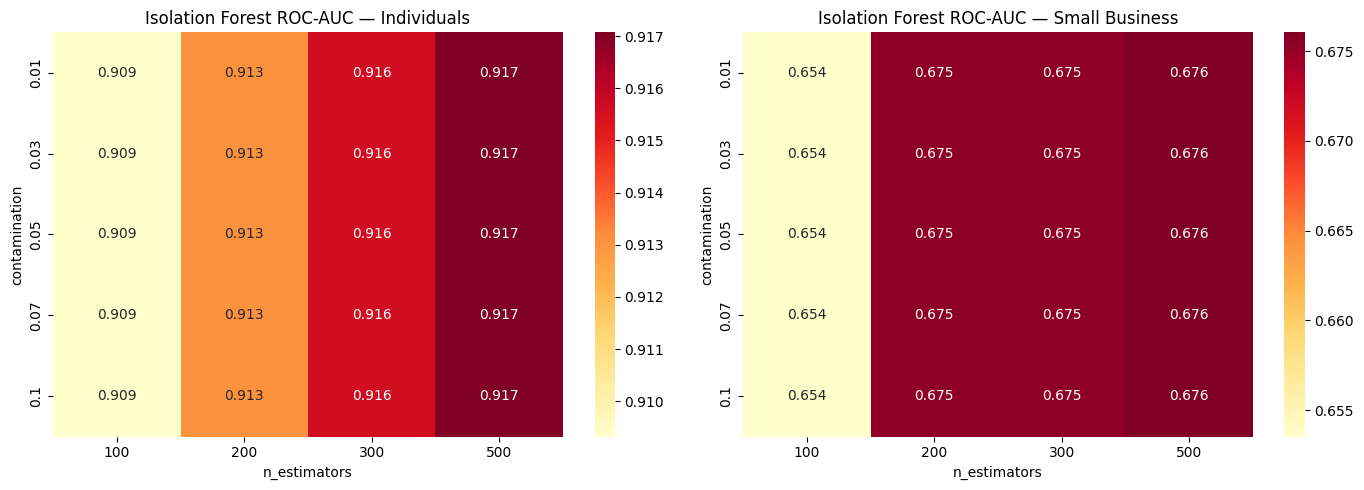

In [20]:
# Heatmap: contamination vs n_estimators (averaged over other params)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes,
                          [iso_results_ind, iso_results_bus],
                          ['Individuals', 'Small Business']):
    pivot = df.groupby(['contamination', 'n_estimators'])['roc_auc'].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'Isolation Forest ROC-AUC — {title}')

plt.tight_layout()
plt.savefig('iso_forest_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Best params for Isolation Forest
best_iso_ind = iso_results_ind.iloc[0].to_dict()
best_iso_bus = iso_results_bus.iloc[0].to_dict()

print('Best Isolation Forest — Individuals:', best_iso_ind)
print('Best Isolation Forest — Small Biz  :', best_iso_bus)

Best Isolation Forest — Individuals: {'n_estimators': 100, 'contamination': 0.01, 'max_samples': 0.5, 'max_features': 0.5, 'roc_auc': 0.9424446944131983, 'pr_auc': 0.13577445345954472}
Best Isolation Forest — Small Biz  : {'n_estimators': 100, 'contamination': 0.03, 'max_samples': 0.5, 'max_features': 1.0, 'roc_auc': 0.7027027027027027, 'pr_auc': 0.12435038066865275}


---
## 4. XGBoost Hyperparameter Tuning



In [22]:
def get_scale_pos_weight(y):
    neg, pos = (y == 0).sum(), (y == 1).sum()
    return neg / pos

xgb_param_dist = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : randint(3, 9),
    'learning_rate'     : uniform(0.01, 0.29),   # 0.01 – 0.30
    'subsample'         : uniform(0.5, 0.5),     # 0.5 – 1.0
    'colsample_bytree'  : uniform(0.5, 0.5),
    'min_child_weight'  : randint(1, 10),
    'gamma'             : uniform(0, 0.5),
    'reg_alpha'         : uniform(0, 1.0),
    'reg_lambda'        : uniform(0.5, 4.5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_xgboost(X, y, param_dist, label='dataset', n_iter=80):
    spw = get_scale_pos_weight(y)
    base_model = XGBClassifier(
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    print(f'[{label}] Starting RandomizedSearchCV ({n_iter} iterations, 5-fold CV) ...')
    search.fit(X, y)
    print(f'[{label}] Best ROC-AUC: {search.best_score_:.4f}')
    return search

xgb_search_ind = tune_xgboost(X_ind, y_ind, xgb_param_dist, label='Individuals')
xgb_search_bus = tune_xgboost(X_bus, y_bus, xgb_param_dist, label='Small Business')

[Individuals] Starting RandomizedSearchCV (80 iterations, 5-fold CV) ...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[Individuals] Best ROC-AUC: 0.9696
[Small Business] Starting RandomizedSearchCV (80 iterations, 5-fold CV) ...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[Small Business] Best ROC-AUC: nan


In [17]:
print(f"Total bus customers: {len(X_bus)}")
print(f"Fraud cases: {y_bus.sum()}")


Total bus customers: 78
Fraud cases: 4.0


In [23]:
print('Best XGBoost params — Individuals:')
for k, v in xgb_search_ind.best_params_.items():
    print(f'  {k}: {v}')
print(f'  -> CV ROC-AUC: {xgb_search_ind.best_score_:.4f}')

print('\nBest XGBoost params — Small Business:')
for k, v in xgb_search_bus.best_params_.items():
    print(f'  {k}: {v}')
print(f'  -> CV ROC-AUC: {xgb_search_bus.best_score_:.4f}')

Best XGBoost params — Individuals:
  colsample_bytree: 0.8501789149863856
  gamma: 0.42333057111915295
  learning_rate: 0.25833404464464677
  max_depth: 8
  min_child_weight: 8
  n_estimators: 260
  reg_alpha: 0.6420316461542878
  reg_lambda: 0.8786298424777197
  subsample: 0.5808143570473069
  -> CV ROC-AUC: 0.9696

Best XGBoost params — Small Business:
  colsample_bytree: 0.6872700594236812
  gamma: 0.4753571532049581
  learning_rate: 0.22227824312530747
  max_depth: 7
  min_child_weight: 5
  n_estimators: 202
  reg_alpha: 0.44583275285359114
  reg_lambda: 0.9498871211810129
  subsample: 0.7296244459829335
  -> CV ROC-AUC: nan


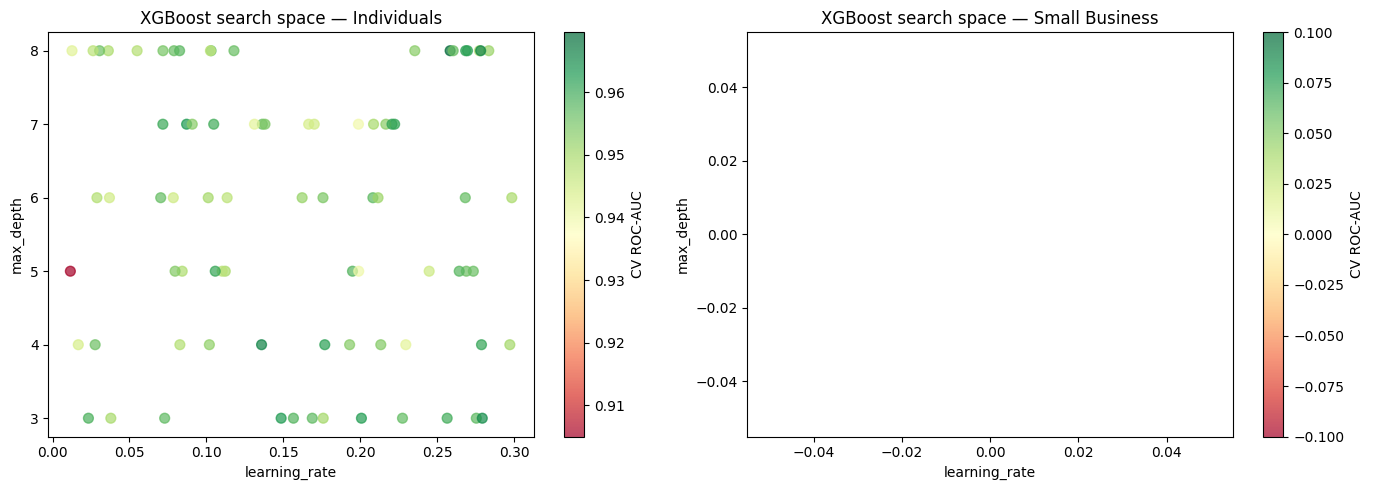

In [24]:
# Learning-rate vs max-depth scatter (coloured by CV score)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, search, title in zip(axes,
                               [xgb_search_ind, xgb_search_bus],
                               ['Individuals', 'Small Business']):
    res = pd.DataFrame(search.cv_results_)
    sc = ax.scatter(
        res['param_learning_rate'],
        res['param_max_depth'],
        c=res['mean_test_score'],
        cmap='RdYlGn', alpha=0.7, s=50
    )
    plt.colorbar(sc, ax=ax, label='CV ROC-AUC')
    ax.set_xlabel('learning_rate')
    ax.set_ylabel('max_depth')
    ax.set_title(f'XGBoost search space — {title}')

plt.tight_layout()
plt.savefig('xgb_search_space.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Evaluate Tuned Models on Full Dataset

In [25]:
def evaluate_xgb(model, X, y, label):
    proba = model.predict_proba(X)[:, 1]
    pred  = model.predict(X)
    print(f'\n=== {label} ===')
    print(f'ROC-AUC          : {roc_auc_score(y, proba):.4f}')
    print(f'Average Precision: {average_precision_score(y, proba):.4f}')
    print(classification_report(y, pred, target_names=['Normal', 'Suspicious']))

evaluate_xgb(xgb_search_ind.best_estimator_, X_ind, y_ind, 'XGBoost — Individuals (train)')
evaluate_xgb(xgb_search_bus.best_estimator_, X_bus, y_bus, 'XGBoost — Small Business (train)')


=== XGBoost — Individuals (train) ===
ROC-AUC          : 1.0000
Average Precision: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       889
  Suspicious       0.60      1.00      0.75         6

    accuracy                           1.00       895
   macro avg       0.80      1.00      0.87       895
weighted avg       1.00      1.00      1.00       895


=== XGBoost — Small Business (train) ===
ROC-AUC          : 1.0000
Average Precision: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        74
  Suspicious       1.00      1.00      1.00         4

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



In [26]:
# Retrain best Isolation Forest with optimal params and compare
def build_best_iso(best_row, X, y, label):
    params = {k: v for k, v in best_row.items()
              if k not in ('roc_auc', 'pr_auc')}
    model = IsolationForest(**params, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X)
    scores = -model.decision_function(X)
    print(f'\n=== {label} ===')
    print(f'ROC-AUC          : {roc_auc_score(y, scores):.4f}')
    print(f'Average Precision: {average_precision_score(y, scores):.4f}')
    return model

best_iso_ind_model = build_best_iso(best_iso_ind, X_ind, y_ind, 'Isolation Forest — Individuals')
best_iso_bus_model = build_best_iso(best_iso_bus, X_bus, y_bus, 'Isolation Forest — Small Business')


=== Isolation Forest — Individuals ===
ROC-AUC          : 0.9424
Average Precision: 0.1358

=== Isolation Forest — Small Business ===
ROC-AUC          : 0.7027
Average Precision: 0.1244


In [28]:

def precision_at_k(model, X, y, k, label):
    scores = -model.decision_function(X)
    top_k_idx = np.argsort(scores)[-k:]
    y_top_k = np.array(y)[top_k_idx]
    p_at_k = y_top_k.sum() / k
    n_fraud_caught = int(y_top_k.sum())
    n_total_fraud = int(y.sum())
    print(f'[{label}] P@{k}: {p_at_k:.4f}  ({n_fraud_caught}/{k} flagged are fraud | {n_fraud_caught}/{n_total_fraud} total fraudsters caught)')

print('=== Precision @ K — Isolation Forest ===\n')

# Individuals
for k in [10, 25, 50, 100]:
    precision_at_k(best_iso_ind_model, X_ind, y_ind, k, 'Individuals')

print()

# Small Business
for k in [5, 10, 20]:
    precision_at_k(best_iso_bus_model, X_bus, y_bus, k, 'Small Biz')


=== Precision @ K — Isolation Forest ===

[Individuals] P@10: 0.2000  (2/10 flagged are fraud | 2/6 total fraudsters caught)
[Individuals] P@25: 0.1200  (3/25 flagged are fraud | 3/6 total fraudsters caught)
[Individuals] P@50: 0.0800  (4/50 flagged are fraud | 4/6 total fraudsters caught)
[Individuals] P@100: 0.0400  (4/100 flagged are fraud | 4/6 total fraudsters caught)

[Small Biz] P@5: 0.0000  (0/5 flagged are fraud | 0/4 total fraudsters caught)
[Small Biz] P@10: 0.1000  (1/10 flagged are fraud | 1/4 total fraudsters caught)
[Small Biz] P@20: 0.1500  (3/20 flagged are fraud | 3/4 total fraudsters caught)


---
## 6. Best Hyperparameters Summary

In [27]:
summary = {
    'Model': [
        'Isolation Forest (Individuals)',
        'Isolation Forest (Small Biz)',
        'XGBoost (Individuals)',
        'XGBoost (Small Biz)',
    ],
    'Best Params': [
        str({k: v for k, v in best_iso_ind.items() if k not in ('roc_auc', 'pr_auc')}),
        str({k: v for k, v in best_iso_bus.items() if k not in ('roc_auc', 'pr_auc')}),
        str(xgb_search_ind.best_params_),
        str(xgb_search_bus.best_params_),
    ],
    'ROC-AUC': [
        round(best_iso_ind['roc_auc'], 4),
        round(best_iso_bus['roc_auc'], 4),
        round(xgb_search_ind.best_score_, 4),
        round(xgb_search_bus.best_score_, 4),
    ]
}

pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(summary))

,Model,Best Params,ROC-AUC
0,Isolation Forest (Individuals),"{'n_estimators': 100, 'contamination': 0.01, 'max_samples': 0.5, 'max_features': 0.5}",0.9424
1,Isolation Forest (Small Biz),"{'n_estimators': 100, 'contamination': 0.03, 'max_samples': 0.5, 'max_features': 1.0}",0.7027
2,XGBoost (Individuals),"{'colsample_bytree': np.float64(0.8501789149863856), 'gamma': np.float64(0.42333057111915295), 'learning_rate': np.float64(0.25833404464464677), 'max_depth': 8, 'min_child_weight': 8, 'n_estimators': 260, 'reg_alpha': np.float64(0.6420316461542878), 'reg_lambda': np.float64(0.8786298424777197), 'subsample': np.float64(0.5808143570473069)}",0.9696
3,XGBoost (Small Biz),"{'colsample_bytree': np.float64(0.6872700594236812), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.22227824312530747), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 202, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.9498871211810129), 'subsample': np.float64(0.7296244459829335)}",NaN
